<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

<font size=6>**Methods**</font>

<div style="border-left: 5px solid #2878b5; padding: 12px 20px; margin: 20px 0;">
  <p style="font-size: 18px; margin: 0 0 8px;">
    <strong>TALES School II</strong><br>
    Hands-on workshop on machine learning applications to astrophysics
  </p>
  <p style="color: #666; margin: 0;">
    September 13–18, 2026 · Petnica Science Center, Serbia
  </p>
</div>

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

Some suggestions on thetechniques you may use to estimate time delays.

- **Cross-correlation**
- **Bayesian Blocks**
- **PyCS: PyCS : Python Curve Shifting**

</div>

# Cross-Correlation

<div style="border-left: 4px solid #4CAF50; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #e8f5e9; color: #1a1a1a;">

**Cross-Correlation** (**CC**) measures how closely 2 time series vary together:

$$
r = \frac{\sum_i (X_i-\bar X)(Y_i-\bar Y)}
{\sqrt{\sum_i (X_i-\bar X)^2}\sqrt{\sum_i (Y_i-\bar Y)^2}}.
$$

A value near $+1$ indicates the perfect correlation.

</div>

## Using Cross-Corrleation to detect time delays

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**Intuition:** If 2 times series are shifted by $\Delta t$, then we can **correct** for that time lag and obtain optimal $r$.

</div>

**In practice:** We do it the other way around — We artificially shift a series, recalculating the $r$, looking for the shift that **maximises** $r$.

$$
\begin{array}{@{}ll}
\hline
&{\textbf{Algorithm: Scan the lag}} \\
\hline
1. & \text{For } \tau=-T,\,-T+1,\,\ldots,\,T:\\
2. & \quad \text{Shift } Y \text{ by } \tau \text{ time units.}\\
3. & \quad r(\tau) \leftarrow \operatorname{corr}\!\bigl(X(t),\,Y(t+\tau)\bigr).\\
4. & \widehat{\Delta t} \leftarrow \underset{\tau \in [-T,T]}{\operatorname{arg\,max}}\;r(\tau).\\
\hline
\end{array}
$$

In [19]:
from IPython.display import Video, display

display(Video("videos/cross_correlation.mp4", embed=False, width=1000))


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### What to watch for

- The **CC** technique assumes the data are just shifted in $\Delta t$, and at most they have different means, but are **identical otherwise**.
> _If the series, e.g., have different trends, those have to be removed <u>before</u> running CC._

- **Gaps/Iregular sampling**
> _See chapter "[$\S$Cross-Correlation when gaps occur](Cross-Correlation-when-gaps-occur)" for a solution._

- **Very noisy series** may create spurious peaks.
> _See chapter "[$\S$Bayesian Blocks + Cross-Correlation](#Bayesian-Blocks-+-Cross-Correlation)" for a solution._


## Cross-Correlation when gaps occur

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff; color: #1a1a1a;">

**Intuition:** As we are iterating over different lags $\tau$, drop the ($X_i$, $Y_i$) pairs where either $X_i$ or $Y_i$ is missing.

</div>

$$
\begin{array}{ll}
\hline
&{\textbf{Algorithm: Find candidate lags with gaps}} \\
\hline
1. & \text{For each trial lag } \tau = -T,\,-T+1,\,\ldots,\,T:\\
2. & \quad \text{Pair } X(t) \text{ with } Y(t+\tau).\\
3. & \quad \text{Remove pairs with missing data.}\\
4. & \quad \text{If enough pairs remain and both series vary:}\\
5. & \qquad r(\tau) \leftarrow \operatorname{correlation}(\text{remaining pairs}).\\
6. & \text{Plot } r(\tau) \text{ against } \tau.\\
7. & \text{Return the lag at the highest valid correlation peak as a candidate.}\\
\hline
\end{array}
$$

# Bayesian Blocks + Cross-Correlation

You have a noisy, unevenly sampled time series and you want to know **where the signal actually
changes** — without first choosing a bin width, a smoothing kernel, or a number of segments.
A histogram needs a bin size; a running mean needs a window. Both impose a timescale on the data
before you have looked at it.

Bayesian Blocks (Scargle et al. 2013) instead lets the **data choose the segmentation**.

## The model

The signal is modelled as **piecewise constant**: the time axis is cut into *blocks*, and inside
each block the data are described by a single level. A block is a maximal stretch over which the
measurements are consistent with one constant value; a block edge (a *change point*) is where
staying constant stops being a good description.

## The objective

Every partition of the points into blocks gets a score:

$$\text{score}(\text{partition}) \;=\; \sum_{\text{blocks}}\Big[\;
   \underbrace{\text{fitness(block)}}_{\text{how well one level fits the points}}
   \;-\; \underbrace{\texttt{ncp\_prior}}_{\text{cost of adding a block}}\;\Big]$$

- **fitness** is the log-likelihood of the best single constant for that block's points. For
  Gaussian errors the best constant is the inverse-variance-weighted mean, and the fitness
  rewards a tight fit to it.
- **`ncp_prior`** is a fixed cost paid once per block. Without it the optimum is *N* one-point
  blocks (a perfect fit). It is set from a **false-alarm probability `p0`** — the probability of
  adding one spurious change point — through an empirical calibration (Scargle 2013, eq. 21).
  Smaller `p0` → larger penalty → fewer blocks.

## How it is solved

There are $2^{N}$ partitions of *N* points, but the best one is found **exactly** in $O(N^2)$.
Let `A(n)` be the best achievable score for the first *n* points. Then

$$A(n) \;=\; \max_{1\le r\le n}\Big[\,A(r-1)\;+\;\text{fitness}(r\ldots n)\;-\;\texttt{ncp\_prior}\,\Big]$$

Sweep *n* from 1 to *N*, remember the arg-max *r* at each step, then backtrack from *N* to read off
the change points. Because each `A(n)` is built on an already-optimal `A(r-1)`, the result is the
global optimum, not a greedy guess.

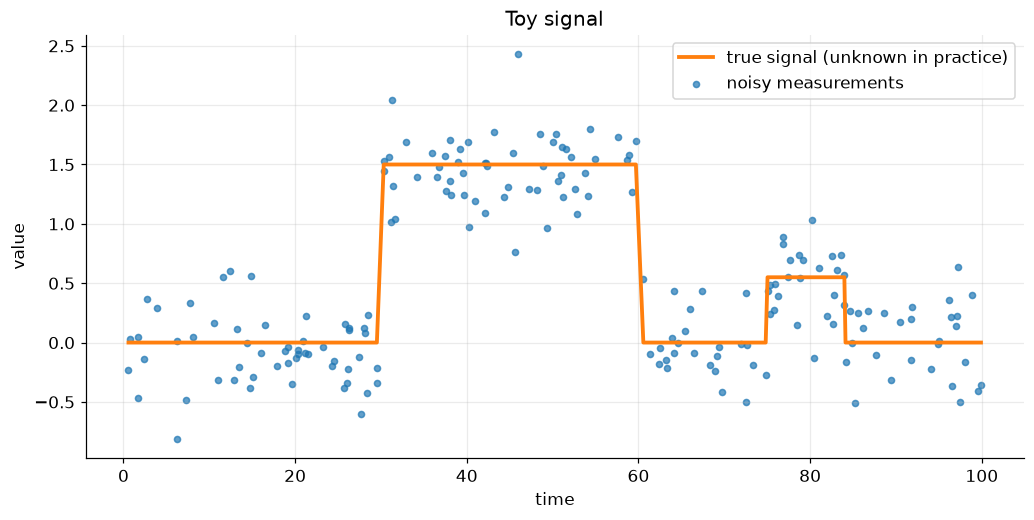

In [9]:
# --- a toy signal whose truth we know: piecewise constant + Gaussian noise ---
t     = np.sort(rng.uniform(0, 100, 190))
truth = np.zeros_like(t)
truth[(t >= 30) & (t < 60)] = 1.50        # a tall, wide feature
truth[(t >= 75) & (t < 84)] = 0.55        # a short, shallow feature
sigma = 0.30
y     = truth + rng.normal(0, sigma, t.size)

fig, ax = plt.subplots()
ax.plot(t, truth, color=PALETTE[1], lw=2.5, label="true signal (unknown in practice)")
ax.scatter(t, y, s=16, color=PALETTE[0], alpha=0.7, label="noisy measurements")
ax.set_xlabel("time"); ax.set_ylabel("value"); ax.set_title("Toy signal")
ax.legend(); plt.show()

In [10]:
# --- Bayesian Blocks written out as the dynamic program ----------------------
def bayesian_blocks_teaching(t, y, sigma, ncp_prior):
    """Exact O(N^2) DP for a piecewise-constant model with a single known sigma.

    Returns (edges, levels). This is the same algorithm astropy runs; the only
    simplification is one scalar sigma instead of a per-point error array.
    """
    N     = len(y)
    edges = np.concatenate([[t[0]], 0.5 * (t[1:] + t[:-1]), [t[-1]]])   # candidate change points

    cs  = np.concatenate([[0], np.cumsum(y)])       # prefix sums -> O(1) block fitness
    cs2 = np.concatenate([[0], np.cumsum(y**2)])
    def fitness(F, R):                              # inclusive sample indices F..R
        n  = R - F + 1
        s1 = cs[R + 1] - cs[F]
        s2 = cs2[R + 1] - cs2[F]
        return -0.5 * (s2 - s1 * s1 / n) / sigma**2      # log-lik of the block mean

    best = np.zeros(N)                              # best score for the first n points
    last = np.zeros(N, dtype=int)                   # where the final block started
    for R in range(N):
        score = np.array([(best[F - 1] if F > 0 else 0.0) + fitness(F, R) - ncp_prior
                          for F in range(R + 1)])
        last[R] = int(np.argmax(score))
        best[R] = score[last[R]]

    cps, i = [N], N - 1                             # backtrack
    while i >= 0:
        cps.append(last[i]); i = last[i] - 1
    cps    = np.array(sorted(set(cps)))
    levels = np.array([y[a:b].mean() for a, b in zip(cps[:-1], cps[1:])])
    return edges[cps], levels

edges, levels = bayesian_blocks_teaching(t, y, sigma, ncp_prior=7.0)
print(f"{len(levels)} blocks; change points at t = {np.round(edges[1:-1], 1)}")
print("true change points were t = [30, 60, 75, 84]")

5 blocks; change points at t = [29.9 60.1 74.9 84.1]
true change points were t = [30, 60, 75, 84]


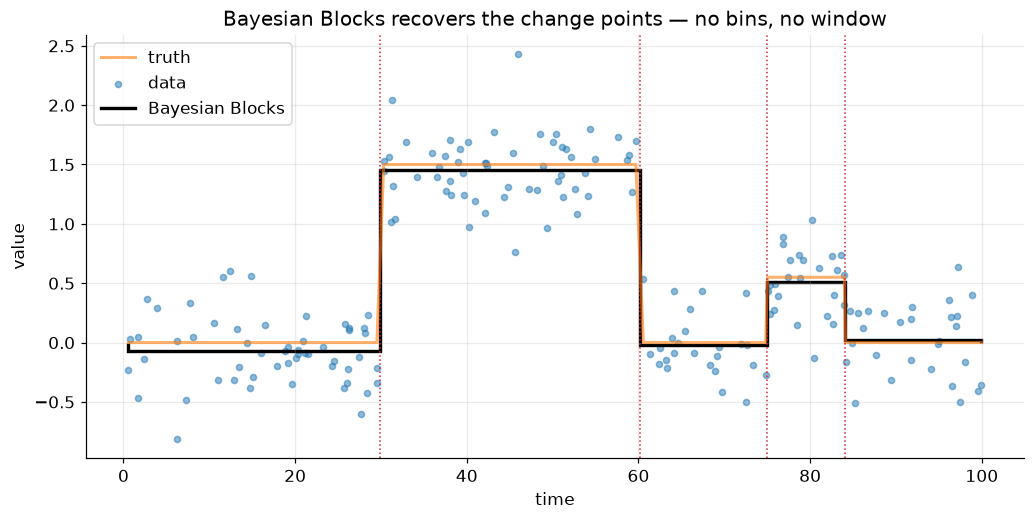

In [11]:
fig, ax = plt.subplots()
ax.plot(t, truth, color=PALETTE[1], lw=2.0, alpha=0.6, label="truth")
ax.scatter(t, y, s=16, color=PALETTE[0], alpha=0.5, label="data")
ax.stairs(levels, edges, color="black", lw=2.2, label="Bayesian Blocks")
for e in edges[1:-1]:
    ax.axvline(e, color=PALETTE[3], ls=":", lw=1.0)
ax.set_xlabel("time"); ax.set_ylabel("value")
ax.set_title("Bayesian Blocks recovers the change points — no bins, no window")
ax.legend(); plt.show()

## The penalty is the only knob

`ncp_prior` (equivalently `p0`) sets the resolution. Too small a penalty splits noise into
spurious blocks; too large merges real features. It is **not** fitted per dataset — a fixed
`p0 ≈ 0.01–0.05` is standard and the result is stable across a wide range.

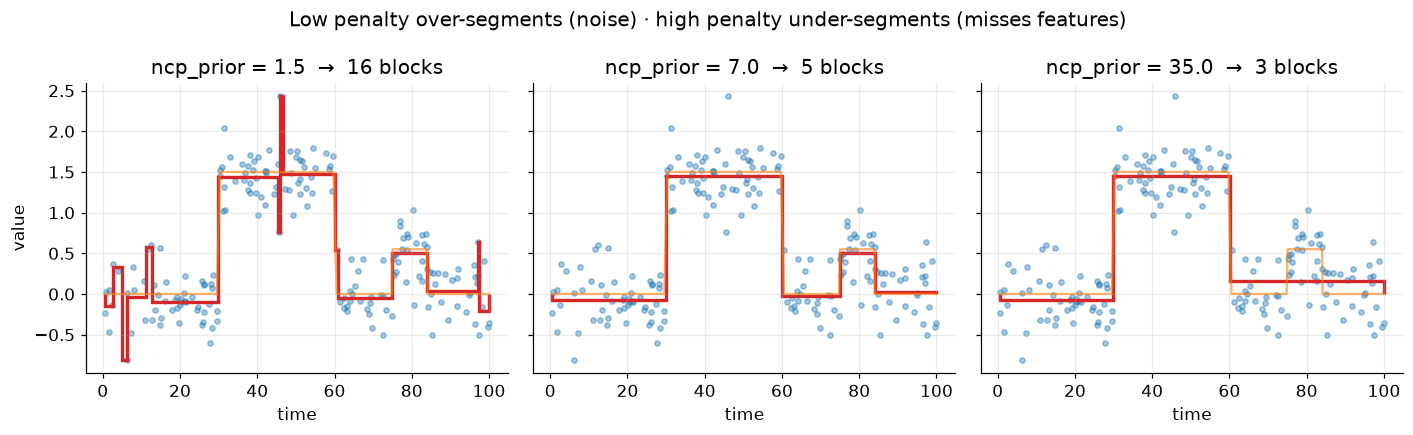

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, ncp in zip(axes, [1.5, 7.0, 35.0]):
    ed, lv = bayesian_blocks_teaching(t, y, sigma, ncp_prior=ncp)
    ax.scatter(t, y, s=12, color=PALETTE[0], alpha=0.4)
    ax.plot(t, truth, color=PALETTE[1], lw=1.5, alpha=0.6)
    ax.stairs(lv, ed, color=PALETTE[3], lw=2.2)
    ax.set_title(f"ncp_prior = {ncp}  →  {len(lv)} blocks")
    ax.set_xlabel("time")
axes[0].set_ylabel("value")
fig.suptitle("Low penalty over-segments (noise) · high penalty under-segments (misses features)")
fig.tight_layout(); plt.show()

In [13]:
# --- astropy runs the identical DP, with a per-point sigma and the p0 calibration ---
ap_edges = bayesian_blocks(t, y, sigma=sigma, fitness="measures", p0=0.05)
print("teaching DP       :", np.round(edges, 2))
print("astropy 'measures':", np.round(ap_edges, 2))
print("\nSame change points. astropy adds per-point errors, the p0→ncp_prior calibration,")
print("and O(N) memory. The recurrence in 1.4 is exactly what it does.")

teaching DP       : [ 0.58 29.92 60.13 74.93 84.06 99.9 ]
astropy 'measures': [ 0.58 29.92 60.13 74.93 84.06 99.9 ]

Same change points. astropy adds per-point errors, the p0→ncp_prior calibration,
and O(N) memory. The recurrence in 1.4 is exactly what it does.


In [ ]:
#EOF